# loading data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset Iris ke dalam DataFrame Pandas
iris_df = pd.read_csv('Iris.csv')

#memberikan info terkait dataframe yang ada
iris_df.info()

# Menampilkan 10 baris pertama data untuk verifikasi awal
iris_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


# analisis data



#### menampilkan ringkasan statistik

In [3]:
# Menampilkan ringkasan statistik data numerik
iris_df.drop(columns='Id', errors='ignore').describe()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


#### cek nilai kosong

In [4]:
# Mengecek apakah ada nilai yang kosong/NaN
print("Jumlah data kosong tiap kolom:")
print(iris_df.isnull().sum())


Jumlah data kosong tiap kolom:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


#### cek distibusi kelas

In [5]:
# Melihat proporsi masing-masing spesies
print("Jumlah data per spesies:")
print(iris_df['Species'].value_counts())


Jumlah data per spesies:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


#### cek duplikat data

In [6]:
# Menampilkan semua baris data yang duplikat (mengabaikan kolom 'Id')
iris_df[iris_df.drop(columns='Id').duplicated(keep=False)]


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
9,10,4.9,3.1,1.5,0.1,Iris-setosa
34,35,4.9,3.1,1.5,0.1,Iris-setosa
37,38,4.9,3.1,1.5,0.1,Iris-setosa
101,102,5.8,2.7,5.1,1.9,Iris-virginica
142,143,5.8,2.7,5.1,1.9,Iris-virginica


#### distribusi data

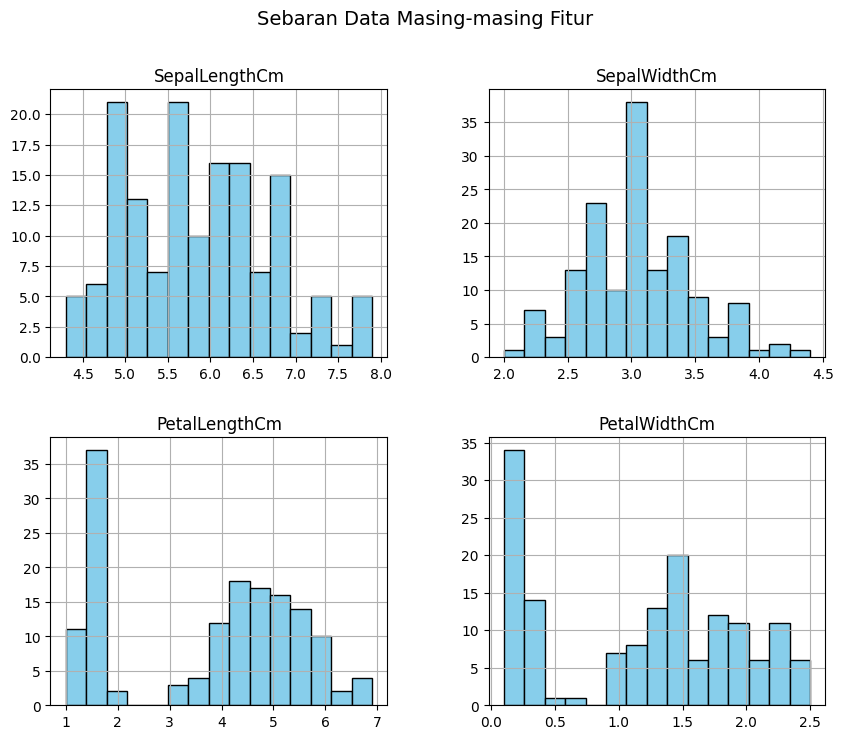

In [7]:
# Membuat histogram untuk semua fitur numerik (tanpa kolom 'Id')
iris_df.drop(columns='Id').hist(figsize=(10, 8), bins=15, color='skyblue', edgecolor='black')

plt.suptitle("Sebaran Data Masing-masing Fitur", fontsize=14)
plt.show()


#### 

#### cek outlier

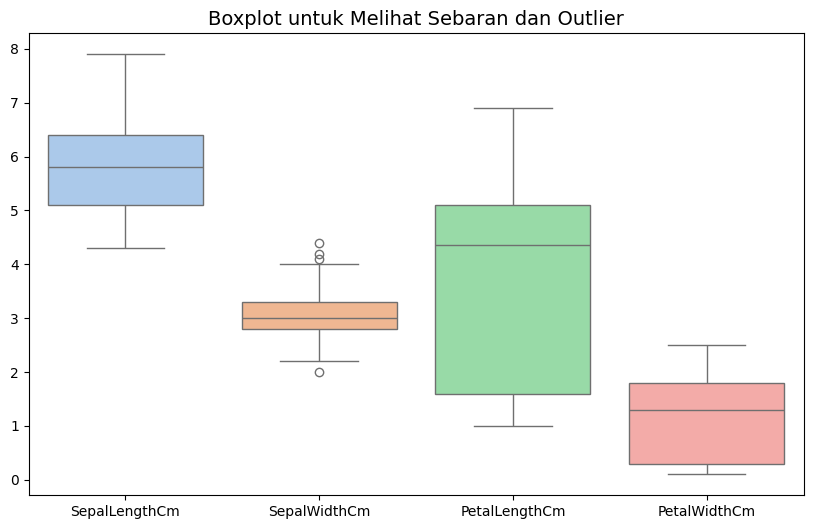

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=iris_df.drop(columns='Id'), palette='pastel')

plt.title("Boxplot untuk Melihat Sebaran dan Outlier", fontsize=14)
plt.show()


#### menampilkan korelasi fitur dan label

<Axes: >

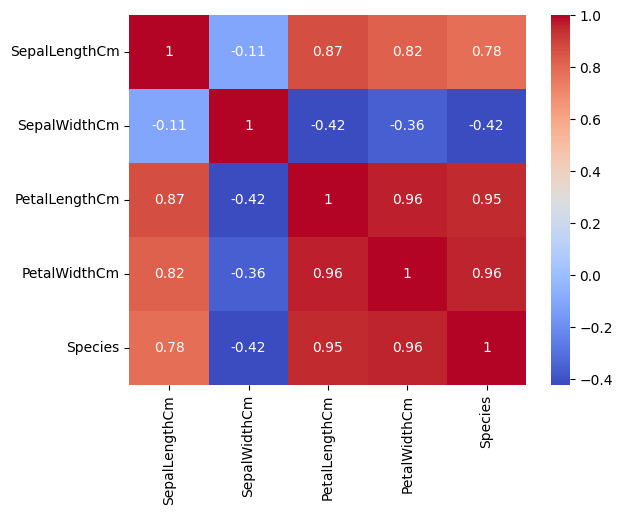

In [9]:
# Ubah label teks jadi angka, hapus kolom 'Id', dan langsung buat heatmap
sns.heatmap(iris_df.assign(Species=iris_df['Species'].astype('category').cat.codes).drop(columns='Id').corr(), annot=True, cmap='coolwarm')


# preprocessing


#### inisiasi variable yang tidak mengandung id

In [10]:
clean_df=iris_df.drop(columns="Id")

#### buang data duplikat

In [11]:
# Menghapus duplikat (mengabaikan kolom 'Id')
clean_df = clean_df.drop_duplicates()

# Menampilkan distribusi kelas setelah duplikat dihapus
print("Distribusi spesies setelah duplikat dihapus:")
print(clean_df['Species'].value_counts())


Distribusi spesies setelah duplikat dihapus:
Species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64


3 data yang terduplikat telah berhasil untuk dibuang 

#### scalling data

In [12]:
from sklearn.preprocessing import StandardScaler

# Memisahkan fitur (X) dan target/label (y)
X = clean_df.drop(columns= 'Species')
y = clean_df['Species']

# Inisialisasi dan melakukan scaling pada data fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Menampilkan 5 baris pertama dari data yang sudah di-scale
print("Data setelah scaling (5 baris pertama):")
print(X_scaled[:5])


Data setelah scaling (5 baris pertama):
[[-0.91550949  1.0199714  -1.35773692 -1.33570001]
 [-1.15755966 -0.12808217 -1.35773692 -1.33570001]
 [-1.39960983  0.33113926 -1.41477817 -1.33570001]
 [-1.52063491  0.10152855 -1.30069567 -1.33570001]
 [-1.03653457  1.24958212 -1.35773692 -1.33570001]]


#### mengubah label menjadi angka numeric

In [13]:
from sklearn.preprocessing import LabelEncoder

# 1. Mengubah label (y) menjadi integer (0, 1, 2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Menampilkan keterangan hasil encoding dengan jelas dan sederhana
print("Keterangan Hasil Encoding Label:")
for angka, nama_label in enumerate(label_encoder.classes_):
    print(f"Angka {angka} mewakili label: {nama_label}")


print("menampilkan hasil encoding kelas dari baris 1-5")
print(y_encoded[:5])


Keterangan Hasil Encoding Label:
Angka 0 mewakili label: Iris-setosa
Angka 1 mewakili label: Iris-versicolor
Angka 2 mewakili label: Iris-virginica
menampilkan hasil encoding kelas dari baris 1-5
[0 0 0 0 0]


#### split data test dan train

 Menyisihkan 5% data sebagai Data Uji (Test), sisanya 95% akan dipakai untuk K-Fold


In [14]:
from sklearn.model_selection import train_test_split

# X_scaled dan y_encoded adalah data yang sudah Anda proses sebelumnya
X_train_kfold, X_test, y_train_kfold, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.05, random_state=42
)

print(f"Total data keseluruhan: {len(X_scaled)}")
print(f"Data untuk proses K-Fold (95%): {len(X_train_kfold)}")
print(f"Data Uji akhir / Test (5%): {len(X_test)}")


Total data keseluruhan: 147
Data untuk proses K-Fold (95%): 139
Data Uji akhir / Test (5%): 8


# training and testing

#### knn train and test

In [17]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# 1. Menentukan metode validasi silang (Stratified K-Fold dengan n=5)
# Menggunakan StratifiedKFold karena ini masalah klasifikasi agar distribusi kelas seimbang
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Inisialisasi model KNN
knn = KNeighborsClassifier()

# 3. Menentukan ruang pencarian hyperparameter (Grid)
# Anda bisa menyesuaikan angka n_neighbors sesuai keinginan
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 4. Inisialisasi GridSearchCV
# Memasukkan skf ke dalam parameter cv
grid_search = GridSearchCV(
    estimator=knn, 
    param_grid=param_grid, 
    cv=skf, 
    scoring='f1_macro',
)

# 5. Melatih model menggunakan data K-Fold (95% data)
print("Memulai pencarian hyperparameter terbaik...")
grid_search.fit(X_train_kfold, y_train_kfold)

# 6. Menampilkan hasil hyperparameter terbaik pada saat validasi silang
print("=========================================")
print("Hyperparameter Terbaik:", grid_search.best_params_)
print("f1 macro K-Fold Validasi Terbaik: {:.2f}%".format(grid_search.best_score_ * 100))
print("=========================================")

# 7. (Opsional) Menguji model terbaik pada sisa 5% Data Test
best_knn_model = grid_search.best_estimator_
test_accuracy = best_knn_model.score(X_test, y_test)
print("Akurasi pada Data Uji Akhir (Test 5%): {:.2f}%".format(test_accuracy * 100))


Memulai pencarian hyperparameter terbaik...
Hyperparameter Terbaik: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
f1 macro K-Fold Validasi Terbaik: 97.19%
Akurasi pada Data Uji Akhir (Test 5%): 87.50%
